# Importing Libraries

In [1]:
# for numerical operations
import numpy as np

# to store and analysis data in dataframes
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# import systemcheck

# python modules for data normalization and splitting 
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# python modules for creating training and testing ml algorithms
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, f1_score, precision_score, recall_score, precision_recall_curve

sns.set()

# Data Acquisition

In [2]:
load_data = pd.read_csv('creditcard.csv')

load_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [6]:
amount_col = load_data['Amount']
class_col = load_data['Class']
time_col = load_data['Time']

# Data Analysis

In [20]:
load_data.shape

(284807, 31)

In [21]:
load_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [22]:
load_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Fraud:  0.001727485630620034


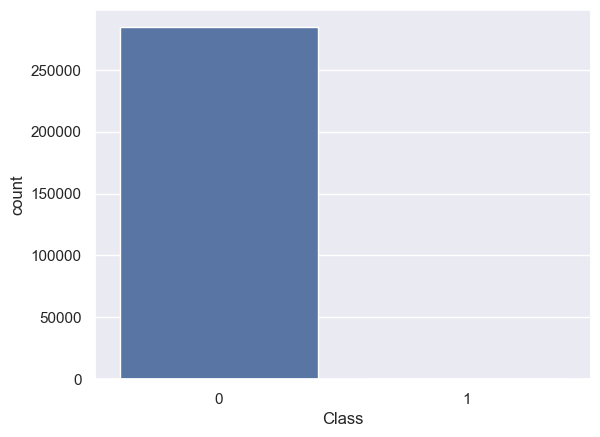

In [23]:
sns.countplot(x='Class', data=load_data)
print("Fraud: ",load_data.Class.sum()/load_data.Class.count())

/var/folders/4h/5mdfqnjn5bjg3wvl8blvql6m0000gn/T/ipykernel_558/1693408604.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  Fraud_class.apply(pd.value_counts).plot(kind='pie',subplots=True)


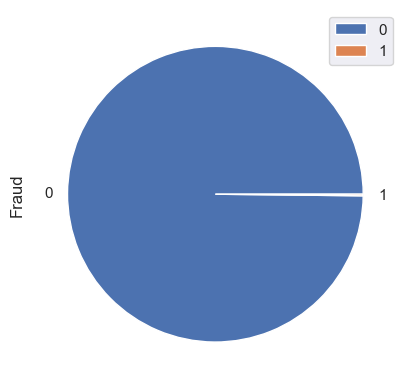

In [24]:
Fraud_class = pd.DataFrame({'Fraud': load_data['Class']})
Fraud_class.apply(pd.value_counts).plot(kind='pie',subplots=True)
plt.show()

In [25]:
fraud = load_data[load_data['Class'] == 1] 
valid = load_data[load_data['Class'] == 0]

In [28]:
print(f"Fraud transaction count: {fraud.Class.count()}")
print(f"Normal transaction count: {(valid.Class.count())}")

Fraud transaction count: 492
Normal transaction count: 284315


In [10]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

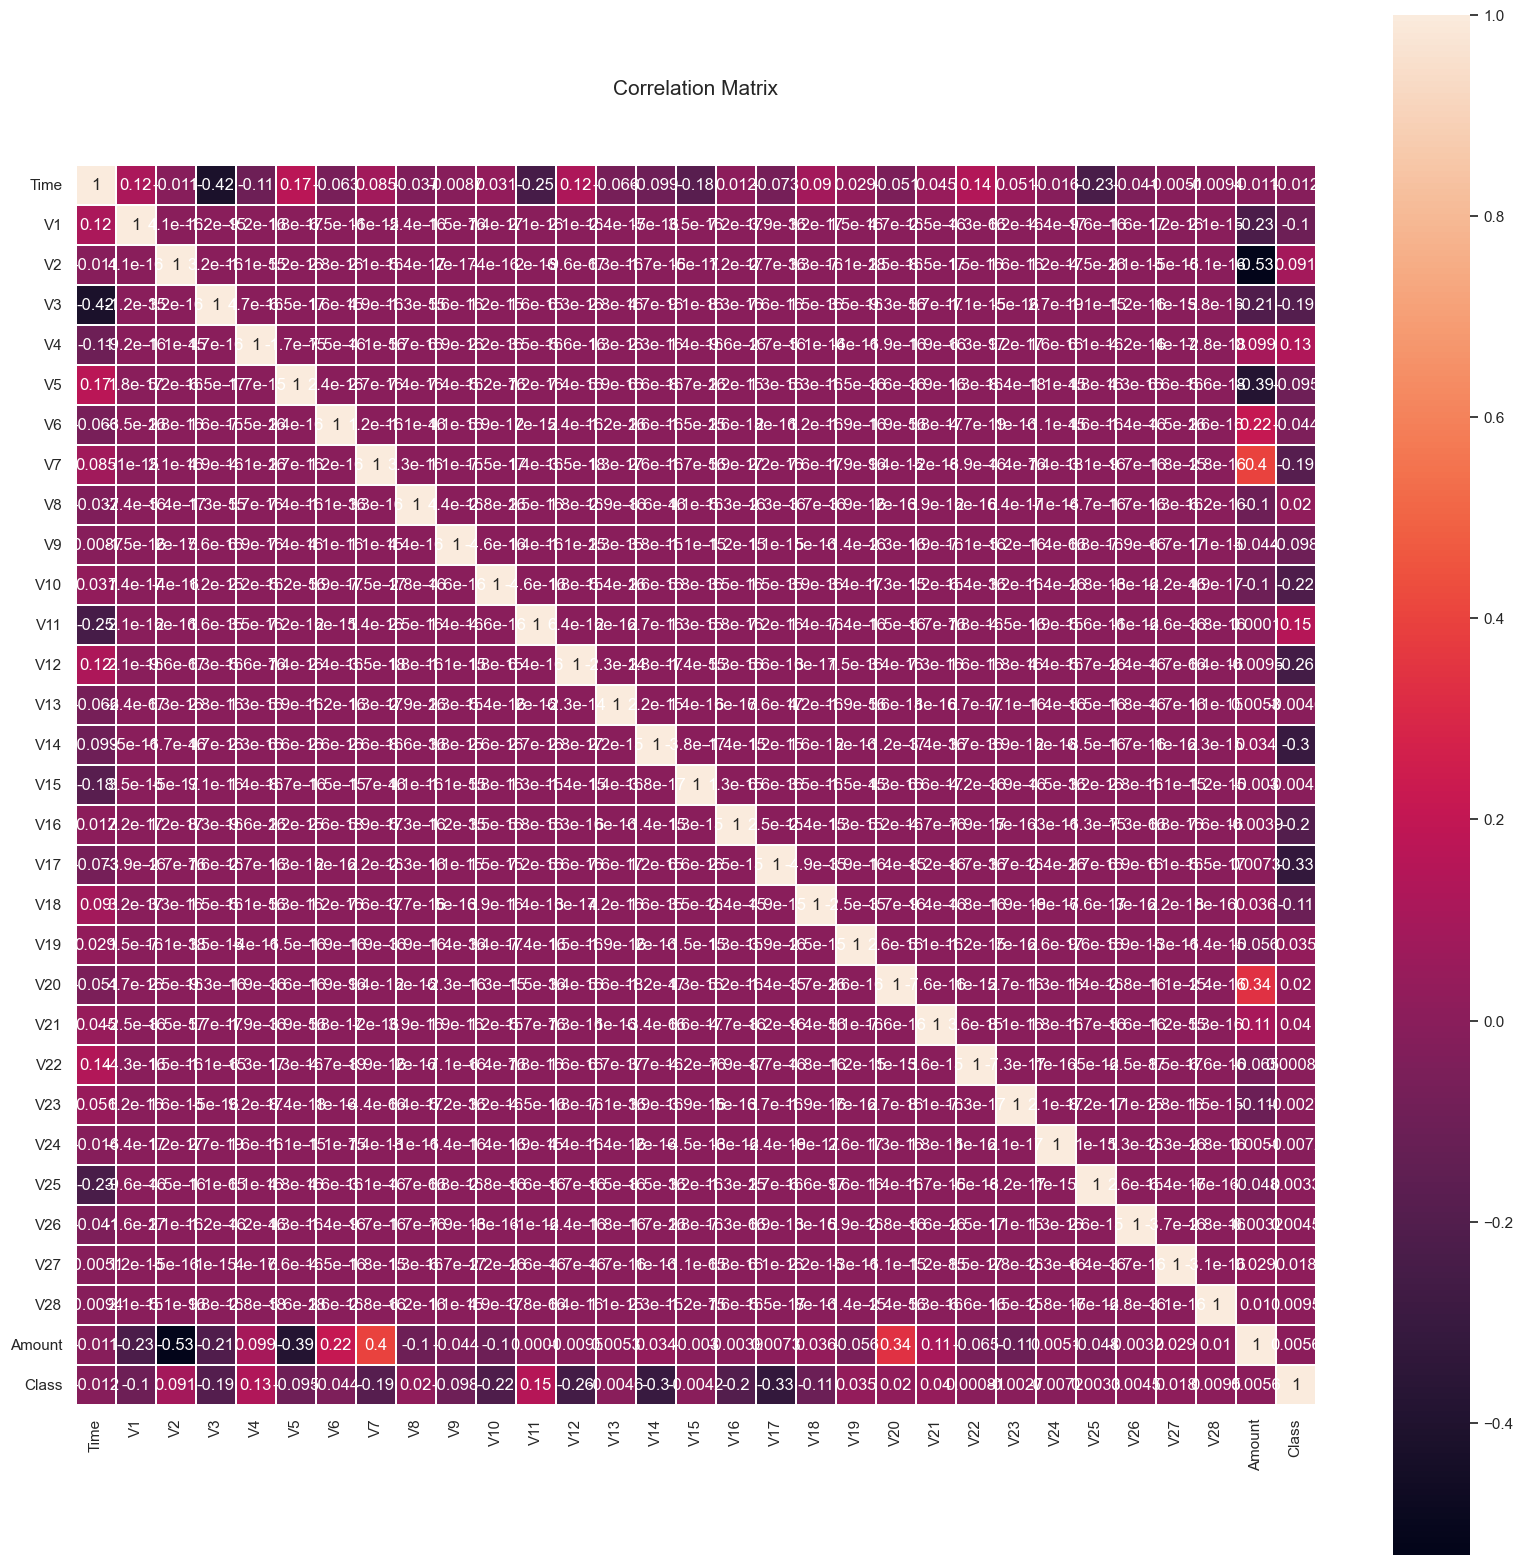

In [11]:
plt.figure(figsize=(20,20))
plt.title('Correlation Matrix', y=1.05, size=15)
sns.heatmap(load_data.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, linecolor='white', annot=True)
plt.show()

# PCA: Application for Feature selection

In [3]:
df = load_data.drop(columns=['Time', 'Amount', 'Class'])

col_num = 10
pca = PCA(n_components=col_num)
pca.fit(df)

PCA(n_components=10)

# Reduced Columns

In [4]:
columns = ['V%i' % i for i in range(col_num)]
df_pca = pd.DataFrame(pca.transform(df), columns=columns, index=df.index)
df_pca.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9
0,1.359824,0.072830,-2.536309,1.378315,0.338197,0.462674,0.239000,-0.096783,0.365112,-0.092916
1,-1.191859,-0.266258,-0.166478,0.448264,-0.059934,-0.082692,-0.079165,-0.084981,-0.253215,0.168032
2,1.358298,1.340581,-1.773456,0.378610,0.503190,1.800990,0.793825,-0.258925,-1.531901,-0.191243
3,0.966274,0.185332,-1.792896,-0.863285,0.010122,1.247449,0.236932,-0.377379,-1.386270,0.063318
4,1.158255,-0.877554,-1.548685,0.403116,0.406960,0.096572,0.592463,0.272099,0.816492,-0.756908


# Final Data Creation

In [7]:
df_pca['Time'] = time_col.values
df_pca['Amount'] = amount_col.values
df_pca['Class'] = class_col.values

data = df_pca.copy()
data.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,Time,Amount,Class
0,1.359824,0.072830,-2.536309,1.378315,0.338197,0.462674,0.239000,-0.096783,0.365112,-0.092916,0.0,149.62,0
1,-1.191859,-0.266258,-0.166478,0.448264,-0.059934,-0.082692,-0.079165,-0.084981,-0.253215,0.168032,0.0,2.69,0
2,1.358298,1.340581,-1.773456,0.378610,0.503190,1.800990,0.793825,-0.258925,-1.531901,-0.191243,1.0,378.66,0
3,0.966274,0.185332,-1.792896,-0.863285,0.010122,1.247449,0.236932,-0.377379,-1.386270,0.063318,1.0,123.50,0
4,1.158255,-0.877554,-1.548685,0.403116,0.406960,0.096572,0.592463,0.272099,0.816492,-0.756908,2.0,69.99,0


# Data Scaling

In [15]:
rs = RobustScaler()
data['Amount'] = rs.fit_transform(data['Amount'].values.reshape(-1, 1))
data['Time'] = rs.fit_transform(data['Time'].values.reshape(-1, 1))
data

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,Time,Amount,Class
0,1.359939,0.072884,-2.536341,1.377170,0.345260,0.463554,0.233248,-0.089608,0.356045,-0.093349,-0.994983,1.783274,0
1,-1.191866,-0.266011,-0.166536,0.448594,-0.057857,-0.082197,-0.079228,-0.085141,-0.263052,0.154946,-0.994983,-0.269825,0
2,1.358498,1.340225,-1.773139,0.378871,0.510768,1.801948,0.779005,-0.232451,-1.525533,-0.227880,-0.994972,4.983721,0
3,0.966053,0.184957,-1.792776,-0.861565,-0.003634,1.244874,0.246484,-0.392842,-1.369924,0.059874,-0.994972,1.418291,0
4,1.158316,-0.877759,-1.548693,0.402266,0.410411,0.096678,0.589468,0.275877,0.819132,-0.748599,-0.994960,0.670579,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,11.881052,-10.071979,9.834945,-2.064424,5.364460,-2.604961,-4.936783,-7.289566,1.942400,-4.340136,1.034951,-0.296653,0
284803,0.732836,0.054999,-2.034895,-0.739473,-0.867783,1.058063,0.019737,-0.288679,0.579702,0.979190,1.034963,0.038986,0
284804,-1.919494,0.301256,3.249624,-0.559783,-2.628963,3.030817,-0.299482,-0.704270,0.426616,0.487878,1.034975,0.641096,0
284805,0.240907,-0.530028,-0.702574,0.686319,0.404735,0.627609,-0.708572,-0.645825,0.359806,0.380670,1.034975,-0.167680,0


## Let's try training the model without balancing the data

In [16]:
# Split the data into training and testing sets balanced data
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 1)

High precision means you don't make many mistakes, 

High recall means you find most of what you're searching for.

In [17]:
clf = LogisticRegression() # initiating logistic regression
clf.fit(X_train, y_train) # Training (Takes around 30 seconds)
pred = clf.predict(X_test) # Testing

print("Accuracy: ", accuracy_score(y_test, pred))
print("f1 score: ", f1_score(y_test, pred))
print("precision score: ", precision_score(y_test, pred))
print("recall score: ", recall_score(y_test, pred))
precision, recall, thresholds = precision_recall_curve(y_test, pred)

Accuracy:  0.9990519995786665
f1 score:  0.625
precision score:  0.7894736842105263
recall score:  0.5172413793103449


In [18]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56875
           1       0.79      0.52      0.62        87

    accuracy                           1.00     56962
   macro avg       0.89      0.76      0.81     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
print(confusion_matrix(y_test, pred))

[[56863    12]
 [   42    45]]


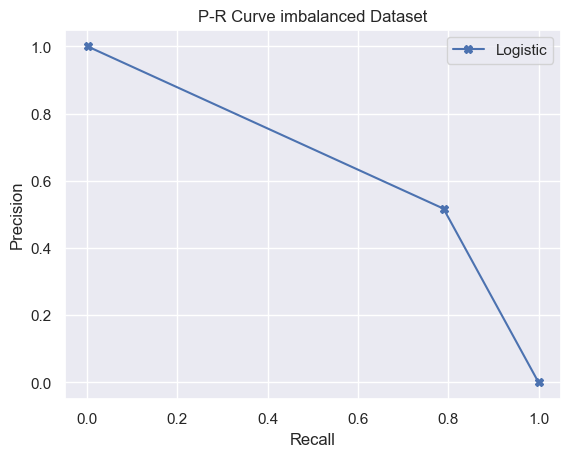

In [20]:
plt.plot(precision, recall, marker='X', label='Logistic')
plt.title("P-R Curve imbalanced Dataset")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

**************************************************

**************************************************

# Data Balancing

In [21]:
print(X.shape)
print(Y.value_counts())
print()

(284807, 12)
Class
0    284315
1       492
Name: count, dtype: int64



## Resampling - Undersampling

In [22]:
under = RandomUnderSampler(random_state=42)
X_bal_under, Y_bal_under = under.fit_resample(X, Y)
print(X_bal_under.shape)
print(Y_bal_under.value_counts())
print()

(984, 12)
Class
0    492
1    492
Name: count, dtype: int64



In [23]:
Us_data = pd.concat([pd.DataFrame(X_bal_under),pd.DataFrame(Y_bal_under)],axis=1)
Us_data

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,Time,Amount,Class
138028,-1.314569,-0.590608,0.666605,0.716726,-0.302659,-1.125881,0.392407,0.283638,-0.135242,0.597152,-0.026340,-0.296793,0
63099,0.798814,-1.184984,-0.904546,0.693328,-0.211397,-0.318283,0.488555,-0.130484,-0.769317,-0.183207,-0.401062,-0.249004,0
73411,0.391378,0.245865,-1.122101,-1.310041,0.656098,0.010844,-0.712686,0.044486,-2.639536,-2.088044,-0.347361,-0.097813,0
164247,0.060361,-1.065185,0.987492,-0.030523,-0.175123,-1.348411,0.773621,-0.132815,-0.153638,1.244568,0.374534,0.489066,0
148999,-1.848722,-0.373808,-0.269247,3.868202,-0.109821,0.968009,-0.709100,-0.253722,0.710812,-1.144422,0.067458,-0.307413,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,1.927625,-1.125876,4.518391,1.752391,1.550434,-2.012308,-0.871594,-0.716846,-2.068694,5.596978,0.992140,5.142178,1
280143,-1.378717,-1.289549,5.004342,1.413121,-0.454696,-1.328672,-1.403397,-0.262003,-1.126106,3.240983,0.994549,-0.296793,1
280149,0.675918,-1.126721,2.213765,0.470523,1.103566,-0.005142,-2.226757,-1.222674,-0.645206,3.481572,0.994596,0.780968,1
281144,3.113568,-0.586122,5.399793,1.819754,0.823281,-2.945987,-2.194580,-1.078949,-1.632878,5.258291,1.001821,3.116048,1


In [24]:
Us_data.Class.value_counts()

Class
0    492
1    492
Name: count, dtype: int64

Fraud:  0.5


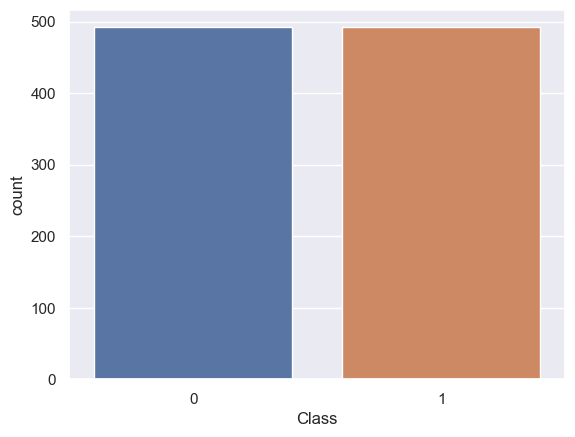

In [25]:
sns.countplot(x='Class', data=Us_data)
print("Fraud: ",Us_data.Class.sum()/Us_data.Class.count())

In [26]:
# Split the data into training and testing sets balanced data
X_train, X_test, y_train, y_test = train_test_split(X_bal_under, Y_bal_under, test_size = 0.2, random_state = 1)

In [27]:
clf = LogisticRegression() # initiating logistic regression
clf.fit(X_train, y_train) # Training (Takes around 30 seconds)
pred = clf.predict(X_test) # Testing

print("Accuracy: ", accuracy_score(y_test, pred))
print("f1 score: ", f1_score(y_test, pred))
print("precision score: ", precision_score(y_test, pred))
print("recall score: ", recall_score(y_test, pred))
precision, recall, thresholds = precision_recall_curve(y_test, pred)

Accuracy:  0.9086294416243654
f1 score:  0.9072164948453608
precision score:  0.9565217391304348
recall score:  0.8627450980392157


In [28]:
print(confusion_matrix(y_test, pred))

[[91  4]
 [14 88]]


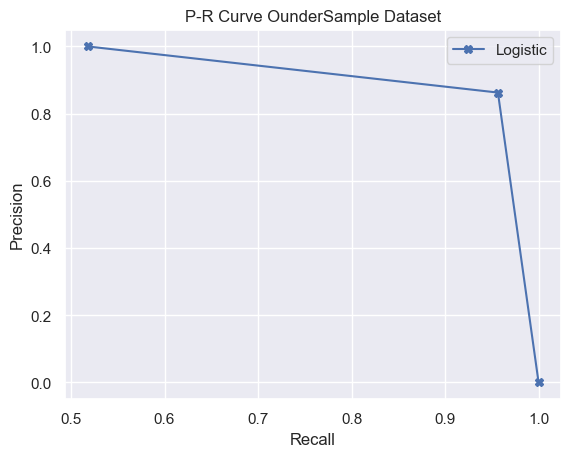

In [29]:
plt.plot(precision, recall, marker='X', label='Logistic')
plt.title("P-R Curve UnderSample Dataset")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

*********************

*********************

## Oversampling

In [9]:
data = data.head(10000)
# Split the data into training and testing sets balanced data
X = data.drop(['Class'], axis = 1)
Y = data["Class"]

print(Y.value_counts())

Class
0    9962
1      38
Name: count, dtype: int64


In [44]:
over = RandomOverSampler(random_state=42)
X_bal_over, Y_bal_over = over.fit_resample(X, Y)
print(X_bal_over.shape)
print(Y_bal_over.value_counts())
print()

(19924, 12)
Class
0    9962
1    9962
Name: count, dtype: int64



In [45]:
Os_data = pd.concat([pd.DataFrame(X_bal_over),pd.DataFrame(Y_bal_over)],axis=1)
Os_data

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,Time,Amount,Class
0,1.359939,0.072884,-2.536341,1.377170,0.345260,0.463554,0.233248,-0.089608,0.356045,-0.093349,-0.994983,1.783274,0
1,-1.191866,-0.266011,-0.166536,0.448594,-0.057857,-0.082197,-0.079228,-0.085141,-0.263052,0.154946,-0.994983,-0.269825,0
2,1.358498,1.340225,-1.773139,0.378871,0.510768,1.801948,0.779005,-0.232451,-1.525533,-0.227880,-0.994972,4.983721,0
3,0.966053,0.184957,-1.792776,-0.861565,-0.003634,1.244874,0.246484,-0.392842,-1.369924,0.059874,-0.994972,1.418291,0
4,1.158316,-0.877759,-1.548693,0.402266,0.410411,0.096678,0.589468,0.275877,0.819132,-0.748599,-0.994960,0.670579,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19919,3.890382,-7.099761,11.426901,8.615954,2.007414,-2.993649,-8.101756,-3.028018,-6.266775,13.213068,-0.858363,-0.293440,1
19920,-0.009056,-4.138531,6.240888,6.680227,-0.811916,-3.359683,-1.594517,-0.207646,-2.774394,6.218260,-0.906566,-0.293440,1
19921,3.499180,-0.258430,4.489642,4.856422,6.980454,3.631720,5.430791,1.940947,-0.798815,1.968358,-0.888497,24.979809,1
19922,2.535190,-5.794375,7.618687,6.401166,0.019266,-3.143095,-3.069798,-1.875744,-3.858907,7.322735,-0.890588,-0.293440,1


In [46]:
Os_data.Class.value_counts()

Class
0    9962
1    9962
Name: count, dtype: int64

Fraud:  0.5


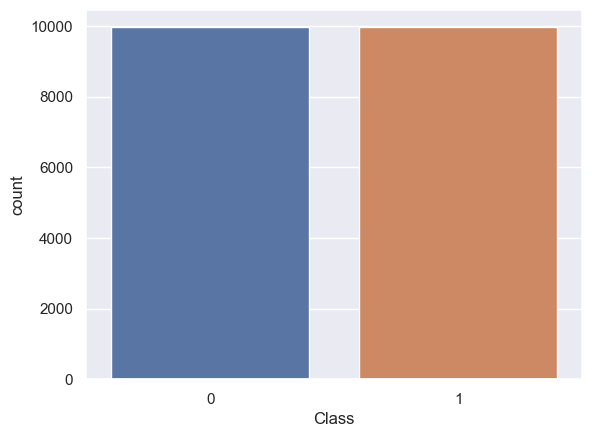

In [47]:
sns.countplot(x='Class', data=Os_data)
print("Fraud: ",Os_data.Class.sum()/Os_data.Class.count())

In [48]:
# Split the data into training and testing sets balanced data
X_train, X_test, y_train, y_test = train_test_split(X_bal_over, Y_bal_over, test_size = 0.2, random_state = 1)

In [49]:
clf = LogisticRegression() # initiating logistic regression
clf.fit(X_train, y_train) # Training (Takes around 30 seconds)
pred = clf.predict(X_test) # Testing

print("Accuracy: ", accuracy_score(y_test, pred))
print("f1 score: ", f1_score(y_test, pred))
print("precision score: ", precision_score(y_test, pred))
print("recall score: ", recall_score(y_test, pred))
precision, recall, thresholds = precision_recall_curve(y_test, pred)

Accuracy:  0.9982434127979924
f1 score:  0.9982074263764404
precision score:  0.9964212678936605
recall score:  1.0


In [50]:
print(confusion_matrix(y_test,pred))

[[2029    7]
 [   0 1949]]


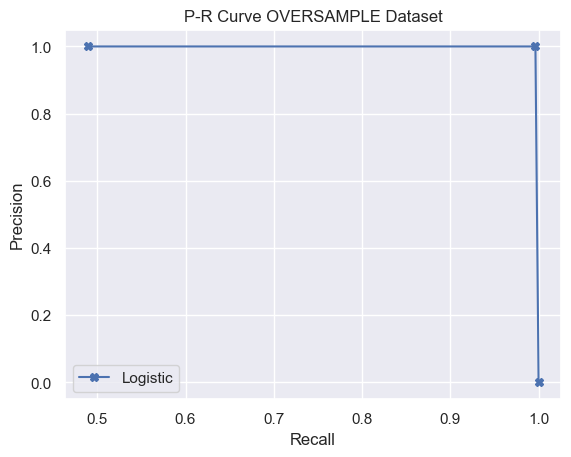

In [51]:
plt.plot(precision, recall, marker='X', label='Logistic')
plt.title("P-R Curve OVERSAMPLE Dataset")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

## Test

In [52]:
pred = clf.predict([[1.359815,0.073080,-2.537682,1.377361,0.338536,0.468537,0.235198,-0.092899,0.361815,0.128272,-0.994983,1.783274]])
if pred == [0]:
    print("Normal transaction")
if pred == [1]:
    print("Fraud transaction")

Normal transaction


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [53]:
pred = clf.predict([[-1.081173,-0.416672,-0.862203,-2.521802,-0.004104,-0.564560,-0.123431,-0.219007,-0.661269,-0.646660,-0.589422,-0.286173]])
if pred == [0]:
    print("Normal transaction")
if pred == [1]:
    print("Fraud transaction")

Normal transaction


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
